# MALDI results — LGP full model & per-lipid analysis

This notebook analyzes the cross-validated benchmark reports produced by
`lgp_report` (→ `report_all/`) and `lgp_report_per_lipid` (→ `report_per_lipid/`).

> **Headline metric = test correlation.** Every ranking, table and chart below is
> driven by mean test correlation over the 173 lipids × 8 CV folds; R², RMSE and MSE
> are kept alongside for context.

**Part A — LGP full model** (`report_all/`, all 173 lipids, 8 folds)
1. Best model configuration per model type (family)
1b. Headline table — the best individual model of **every method** (LGP · manifold · spectral · GP-LFR · NTF · SPA3D · DeepSpatial · MLP / XGBoost / GCN / …)
2. Bar plots with fold-derived error bars comparing **correlation** and **MSE**
3. Head-to-head: best **Riemann manifold** vs best **LGP Euclidean** — and the
   lipids where the manifold wins
4. Manifold ablation — matched-pair effect of modes, pruning, atlas annotation & ARD

**Part B — Per-lipid models** (`report_per_lipid/`, 5 focus lipids)
4. Per-lipid bar plots of the dedicated per-lipid models
5. How much does the full LGP model bring *on top* of the best per-lipid model

## Setup

In [4]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---- locate the report folders (run from repo root or from analysis/) -------
ROOT = Path.cwd().parent
if not (ROOT / "output" / "report_all").exists():
    ROOT = ROOT.parent
ALL = ROOT / "output" / "report_all"
PL  = ROOT / "output" / "report_per_lipid"
assert ALL.exists() and PL.exists(), f"report folders not found under {ROOT}"
print("report_all      :", ALL)
print("report_per_lipid:", PL)


report_all      : /home/casap/mlibra_git/reports/output/report_all
report_per_lipid: /home/casap/mlibra_git/reports/output/report_per_lipid


In [5]:
# ---- colour scheme & fonts from manifold_boundary_narrative.ipynb -----------
# semantic palette, identical to the narrative notebook
C_E   = "#68717d"   # Euclidean             (slate)
C_M   = "#e24a4a"   # manifold              (red)
C_EMP = "#111111"   # emphasis / reference  (near-black)
C_S   = "#238b68"   # same-region / gain    (green)
C_X   = "#8b4ea3"   # cross / extra         (purple)
# harmonised extensions for the remaining model families
C_GOLD = "#c98a2b"; C_TAUPE = "#7a6a58"; C_STEEL = "#3f7d9c"

SURFACE = "white"; INK = C_EMP; INK2 = "#555555"

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22,
    "legend.frameon": False, "font.size": 9, "figure.dpi": 110,
})

# per-family colour (Euclidean=slate, manifold=red, spectral=green, GP-LFR=purple)
FAMILY_COLOR = {
    "lgp": C_E, "manifold": C_M, "spectral": C_S, "gplfr": C_X,
    "sota": C_GOLD, "sota-deepspatial": C_TAUPE, "baseline": C_STEEL,
}
DIVER = (C_M, C_E)                     # (manifold, Euclidean) head-to-head poles
PAL = [C_E, C_M, C_S, C_X, C_GOLD, C_TAUPE, C_STEEL, C_EMP]   # back-compat alias

# friendly names for the full-model families
FAMILY_LABEL = {
    "lgp":              "LGP\n(Euclidean Matern)",
    "manifold":         "Riemann\nmanifold",
    "spectral":         "Spectral\n(weight-space)",
    "gplfr":            "GP-LFR",
    "baseline":         "Baselines",
    "sota":             "SOTA\n(NTF / SPA3D)",
    "sota-deepspatial": "DeepSpatial",
}
FAMILY_ORDER = ["lgp", "manifold", "spectral", "gplfr", "sota", "sota-deepspatial", "baseline"]

# lgp_report's derive_family emits finer labels when a run's args.npy loads
# ("baseline-mlp", "baseline-euclid-w0-euclidatlas", "gplfr-euclidean") and coarse
# ones when it does not. Fold both onto the buckets this notebook is built around;
# the MODEL string always carries the full configuration, and method_of() keys on
# that, so no resolution is lost.
import re as _re

# EUCLID run names encode the three settings that change the estimator, with the
# defaults left untagged by run_baseline.sh:
#     -w<W>      only when W != 50   (so "no -w tag" means w=50)
#     -norm<N>   only when N != none (so "no -norm tag" means unnormalised)
#     -<atlas>   euclidatlas | <annotation stem>-<reference stem>
def euclid_arm(model: str) -> dict | None:
    """Parse an EUCLID run/model name into {w, norm, atlas}; None if not EUCLID."""
    if "BASELINES-EUCLID" not in str(model):
        return None
    name = str(model)
    w = _re.search(r"-w([\d.]+)(?=-|$)", name)
    norm = _re.search(r"-norm([a-z]+)(?=-|$)", name)
    atlas = ("leaf atlas" if "euclidatlas" in name
             else (_re.search(r"-(level_\d+annot|ccf_depth\d+annot)", name).group(1)
                   if _re.search(r"-(level_\d+annot|ccf_depth\d+annot)", name) else "?"))
    return {"w": float(w.group(1)) if w else 50.0,
            "norm": norm.group(1) if norm else "none",
            "atlas": atlas}

# The unnormalised w=50 arm is not a usable result: with our ~1e-4 intensities
# every log(x) is negative, so normalize_to_255's NaN-fill 0 becomes the array
# MAX and the rescale tops out well below 255. w=50 then deletes 16-100% of the
# donors depending on the lipid -- about a quarter come back a flat constant, and
# many score bit-identically across two different atlases because the structure
# gate has nothing left to gate. Dropped everywhere in this notebook.
def euclid_is_valid(model: str) -> bool:
    arm = euclid_arm(model)
    if arm is None:
        return True                      # not an EUCLID run; unaffected
    return not (arm["norm"] == "none" and arm["w"] == 50.0)


def family_bucket(family: str) -> str:
    f = str(family)
    for pre in ("sota-deepspatial", "sota", "gplfr", "baseline"):
        if f.startswith(pre):
            return pre
    return f


In [6]:
# ---- load full-model report -----------------------------------------------
per_lipid_model = pd.read_csv(ALL / "per_lipid_model.csv")   # (lipid, model, family) x folds-agg
per_lipid_long  = pd.read_csv(ALL / "per_lipid_long.csv")    # (run, fold, model, lipid) rows
per_lipid_long["mse"] = per_lipid_long["rmse"] ** 2          # MSE = RMSE^2

# normalise family labels so the notebook reads either derive_family vintage
for _df in (per_lipid_model, per_lipid_long):
    if "family" in _df.columns:
        _df["family"] = _df["family"].map(family_bucket)

# Drop EUCLID arms that are not valid results (see euclid_is_valid above), so
# every section below -- A1, A1b, A1c, A2 -- agrees on what exists.
_before = per_lipid_model["model"].nunique()
for _n, _df in (("per_lipid_model", per_lipid_model), ("per_lipid_long", per_lipid_long)):
    _keep = _df["model"].map(euclid_is_valid)
    if not _keep.all():
        globals()[_n] = _df[_keep].reset_index(drop=True)
per_lipid_model, per_lipid_long = globals()["per_lipid_model"], globals()["per_lipid_long"]
_dropped = _before - per_lipid_model["model"].nunique()
if _dropped:
    print(f"dropped {_dropped} EUCLID config(s): unnormalised w=50 (broken -- see note)")

# Keep only configurations scored on EVERY fold the report covers. A config that
# ran on 2 of the 8 folds is averaged over a different subset of held-out mice
# than the configs it is ranked against, so its mean is not comparable -- and
# since drop_duplicates() below picks the single best config per family/method,
# one lucky 2-fold run can win its family outright and inflate that bar.
REQUIRE_ALL_FOLDS = True
N_FOLDS = per_lipid_long["fold"].nunique()
if REQUIRE_ALL_FOLDS and N_FOLDS > 1:
    _nf = per_lipid_long.groupby("model")["fold"].nunique()
    _partial = _nf[_nf < N_FOLDS]
    if len(_partial):
        _fam = (per_lipid_model[per_lipid_model.model.isin(_partial.index)]
                .groupby("family")["model"].nunique().sort_values(ascending=False))
        print(f"dropped {len(_partial)} config(s) scored on < {N_FOLDS} folds "
              f"({', '.join(f'{f}:{n}' for f, n in _fam.items())})")
        for _m, _k in _partial.sort_values().items():
            print(f"    {_k} fold(s)  {_m[:88]}")
        _full = set(_nf[_nf == N_FOLDS].index)
        per_lipid_model = per_lipid_model[per_lipid_model.model.isin(_full)].reset_index(drop=True)
        per_lipid_long  = per_lipid_long[per_lipid_long.model.isin(_full)].reset_index(drop=True)

N_LIPIDS = per_lipid_model["lipid"].nunique()
N_FOLDS  = per_lipid_long["fold"].nunique()
print(f"full model: {N_LIPIDS} lipids x {N_FOLDS} folds")
print("families   :", ", ".join(f"{f}({per_lipid_model[per_lipid_model.family==f].model.nunique()})"
                                 for f in FAMILY_ORDER if f in set(per_lipid_model.family)))


full model: 173 lipids x 8 folds
families   : lgp(8), manifold(19), spectral(34), gplfr(3), sota(11), sota-deepspatial(3), baseline(8)


## A1 — Best model configuration per model type

**Correlation is the headline metric throughout this notebook.** For each **family**
we rank every candidate configuration by its mean test **correlation** across all 173
lipids (each lipid value is itself the mean over the 8 CV folds) and keep the winner.
R² and RMSE are carried along for context.

*(The `MEAN` null baseline predicts a constant, so its correlation is undefined — it is
kept in the tables as `NaN` and dropped from the correlation charts.)*

In [7]:
# aggregate each configuration over lipids -> one row per (family, model)
cfg = (per_lipid_model
       .groupby(["family", "model"])
       .agg(corr=("corr_mean", "mean"), r2=("r2_mean", "mean"),
            rmse=("rmse_mean", "mean"), n_lipids=("lipid", "nunique"),
            n_folds=("n_folds", "max"))
       .reset_index())
# the constant MEAN baseline has undefined correlation -> rank it last, keep the NaN
cfg["corr_rank"] = cfg["corr"].fillna(-np.inf)

# best config per family by mean correlation
best = (cfg.sort_values("corr_rank", ascending=False)
           .drop_duplicates("family", keep="first"))
best["family_ord"] = best["family"].map({f: i for i, f in enumerate(FAMILY_ORDER)})
best = best.sort_values("family_ord").drop(columns="family_ord").reset_index(drop=True)

show = best.copy()
show["family"] = show["family"].map(lambda f: FAMILY_LABEL.get(f, f).replace("\n", " "))
show = show.rename(columns={"family": "model type", "model": "best config"})
show["config (short)"] = show["best config"].str.slice(0, 60) + "..."
disp = show[["model type", "corr", "r2", "rmse", "n_lipids", "n_folds", "config (short)"]]
pd.set_option("display.max_colwidth", 70)
disp.round({"corr": 4, "r2": 4, "rmse": 6})

,model type,corr,r2,rmse,n_lipids,n_folds,config (short)
0,LGP (Euclidean Matern),0.6127,0.3753,0.000598,173,8,LGPALL-MEAN-5-data-2000-1000-learnind-ard10...
1,Riemann manifold,0.6046,0.3646,0.000603,173,8,MANIFOLD-RSAMPLE-5-4-K100-reference-5-data-2000-1000-faiss_a...
2,Spectral (weight-space),0.6033,0.3615,0.000605,173,8,SPECTRAL-5-4-K300-reference-5-1000-faiss_cluster_weighted-50...
3,GP-LFR,0.5275,0.2800,0.000640,173,8,EUCLIDEAN-GPLFR-euclidean-d810...
4,SOTA (NTF / SPA3D),0.5918,0.3506,0.000609,173,8,ZW05-NONE-SOTA-SPA3D-409610...
5,DeepSpatial,0.1891,-15.3364,0.000916,173,8,WITHIN-REG03-DEEPSPATIAL-TRANSPORT-256-6-100-WITHIN-MOUSE10...
6,Baselines,0.6073,0.3705,0.000602,173,8,BASELINES-MLP-25610...


In [8]:
# full winning-config strings (for the record)
for _, r in best.iterrows():
    print(f"[{r['family']:>16}]  corr={r['corr']:.4f}  R2={r['r2']:.4f}")
    print(f"     {r['model']}\n")

[             lgp]  corr=0.6127  R2=0.3753
     LGPALL-MEAN-5-data-2000-1000-learnind-ard10

[        manifold]  corr=0.6046  R2=0.3646
     MANIFOLD-RSAMPLE-5-4-K100-reference-5-data-2000-1000-faiss_atlas_weighted-50-15-randomwalk-2-1.0-0.01-0.1-learndiff1.0-blend0.810

[        spectral]  corr=0.6033  R2=0.3615
     SPECTRAL-5-4-K300-reference-5-1000-faiss_cluster_weighted-50-15-randomwalk-2-1.0-0.01-0.1-1.0-clk64-sw1.0-cs010

[           gplfr]  corr=0.5275  R2=0.2800
     EUCLIDEAN-GPLFR-euclidean-d810

[            sota]  corr=0.5918  R2=0.3506
     ZW05-NONE-SOTA-SPA3D-409610

[sota-deepspatial]  corr=0.1891  R2=-15.3364
     WITHIN-REG03-DEEPSPATIAL-TRANSPORT-256-6-100-WITHIN-MOUSE10

[        baseline]  corr=0.6073  R2=0.3705
     BASELINES-MLP-25610



### A1b — Within-family configuration ranking

The full sweep inside each family: every configuration, ranked by mean test
**correlation**. The top row is the family winner used above; the rest show the
runners-up and how much the hyperparameter choices actually move the metric.
`summary` pulls the distinguishing tokens (mode count `K`, weighting, `prune`, atlas
`annot`, `ard`/`learn*`, sampling) out of the long run name.

In [9]:
import re
from IPython.display import display, Markdown

def config_summary(name):
    """Extract the distinguishing hyperparameter tokens from a run name."""
    # EUCLID arms are named by the two settings that change the estimator, and the
    # generic token list below would render them as raw strings (or, worse, latch
    # onto "level_15annot"/"reference" and hide the w setting). Handle them first.
    arm = euclid_arm(name)
    if arm is not None:
        w = "w=0 (filter off)" if arm["w"] == 0 else f"w={arm['w']:g} (their default)"
        norm = {"none": "unnormalised", "max": "per-lipid max-norm",
                "global": "global norm"}.get(arm["norm"], arm["norm"])
        return f"{w} · {norm} · {arm['atlas']}"
    toks = []
    for pat in [r"K\d+", r"stride\d+", r"prune0?\.?\d+", r"level_\d+annot",
                r"faiss_atlas_weighted", r"faiss_cluster_weighted", r"faiss(?![_a-z])",
                r"randomwalk", r"learndiff[\d.]+", r"learnspecw", r"learnind",
                r"ard\d+", r"prodard[\d.]+", r"blend[\d.]+", r"rootdissolve",
                r"dn\d+", r"ptls", r"RSAMPLE", r"MEAN", r"data", r"reference",
                r"clk\d+", r"TV\d+", r"RES\d+", r"ZW\d+", r"NONE", r"HILBERT",
                r"ALFT", r"NTF", r"SPA3D", r"LINEAR", r"MLP", r"XGBOOST", r"GCN",
                r"MLP_EIGEN", r"NM\d+", r"CROSS", r"WITHIN", r"nu[\d.]+", r"d8"]:
        m = re.search(pat, name)
        if m:
            t = m.group(0)
            if t not in toks:
                toks.append(t)
    return " · ".join(toks) if toks else name[:50]

rank = cfg.copy()
rank["summary"] = rank["model"].map(config_summary)
rank["n_configs_in_family"] = rank.groupby("family")["model"].transform("nunique")

for fam in FAMILY_ORDER:
    if fam not in set(rank.family):
        continue
    g = rank[rank.family == fam].sort_values("corr_rank", ascending=False).reset_index(drop=True)
    label = FAMILY_LABEL.get(fam, fam).replace("\n", " ")
    display(Markdown(f"**{label}**  —  {len(g)} configuration(s), "
                     f"corr range {g["corr"].min():.4f} → {g["corr"].max():.4f}  "
                     f"(spread {g["corr"].max()-g["corr"].min():.4f})"))
    tbl = g[["summary", "corr", "r2", "rmse"]].copy()
    tbl.index = ["★ best"] + [f"#{i}" for i in range(2, len(g) + 1)]
    display(tbl.round({"corr": 4, "r2": 4, "rmse": 7}))

**LGP (Euclidean Matern)**  —  8 configuration(s), corr range 0.5693 → 0.6127  (spread 0.0434)

,summary,corr,r2,rmse
★ best,learnind · ard10 · MEAN · data,0.6127,0.3753,0.000598
#2,learnind · ard10 · MEAN · reference,0.6126,0.3760,0.000598
#3,learnind · ard10 · MEAN · reference,0.5998,0.3293,0.000621
#4,learnind · ard10 · MEAN · data,0.5988,0.3307,0.000620
#5,learnind · ard10 · RSAMPLE · reference,0.5811,0.3185,0.000623
#6,learnind · ard10 · RSAMPLE · data,0.5771,0.3112,0.000627
#7,learnind · ard10 · RSAMPLE · data,0.5697,0.2739,0.000644
#8,learnind · ard10 · RSAMPLE · reference,0.5693,0.2724,0.000644


**Riemann manifold**  —  19 configuration(s), corr range 0.5838 → 0.6046  (spread 0.0208)

,summary,corr,r2,rmse
★ best,K100 · faiss_atlas_weighted · randomwalk · learndiff1.0 · blend0.8...,0.6046,0.3646,0.000603
#2,K100 · prune0.9710 · faiss_atlas_weighted · randomwalk · learndiff...,0.6037,0.3639,0.000603
#3,K100 · prune0.9510 · faiss_atlas_weighted · randomwalk · learndiff...,0.6035,0.3639,0.000603
#4,K100 · prune0.910 · faiss_atlas_weighted · randomwalk · learndiff1...,0.6026,0.3632,0.000604
#5,K100 · prune0.9510 · level_5annot · faiss_atlas_weighted · randomw...,0.6025,0.3629,0.000604
#6,K100 · prune0.9710 · level_5annot · faiss_atlas_weighted · randomw...,0.6020,0.3628,0.000604
#7,K300 · prune0.9510 · faiss_atlas_weighted · randomwalk · learndiff...,0.6009,0.3606,0.000605
#8,K100 · prune0.910 · level_5annot · faiss_atlas_weighted · randomwa...,0.6007,0.3589,0.000606
#9,K300 · prune0.910 · level_5annot · faiss_atlas_weighted · randomwa...,0.6003,0.3581,0.000606
#10,K300 · prune0.910 · faiss_atlas_weighted · randomwalk · learndiff1...,0.5988,0.3558,0.000607


**Spectral (weight-space)**  —  34 configuration(s), corr range 0.5937 → 0.6033  (spread 0.0095)

...

,summary,corr,r2,rmse
★ best,ZW05 · NONE · SPA3D,0.5918,0.3506,0.000609
#2,ZW03 · NONE · SPA3D,0.5906,0.3491,0.000609
#3,ZW03 · NONE · SPA3D,0.5870,0.3459,0.000611
#4,ZW03 · ALFT · SPA3D,0.5660,0.3229,0.000621
#5,ZW01 · NONE · SPA3D,0.5625,0.3174,0.000622
#6,TV05 · RES128 · NTF,0.5164,0.1818,0.000684
#7,TV05 · RES256 · NTF,0.5162,0.1825,0.000685
#8,TV00 · RES256 · NTF,0.5162,0.1801,0.000686
#9,TV20 · RES256 · NTF,0.5161,0.1826,0.000685
#10,TV05 · RES512 · NTF,0.5155,0.1806,0.000684


**DeepSpatial**  —  3 configuration(s), corr range 0.1060 → 0.1891  (spread 0.0831)

,summary,corr,r2,rmse
★ best,WITHIN,0.1891,-15.3364,0.000916
#2,CROSS,0.1114,-106.3456,0.001115
#3,CROSS,0.1060,-7.8800,0.000935


**Baselines**  —  8 configuration(s), corr range 0.2234 → 0.6073  (spread 0.3839)

,summary,corr,r2,rmse
★ best,MLP,0.6073,0.3705,0.000602
#2,prune0.9710 · rootdissolve · dn3 · GCN,0.5911,0.3415,0.000615
#3,prune0.9710 · rootdissolve · dn3 · MLP · MLP_EIGEN · NM300,0.5786,0.2974,0.000633
#4,prune0.9710 · rootdissolve · dn3 · MLP · MLP_EIGEN · NM1300,0.5766,0.3047,0.000628
#5,prune0.9710 · rootdissolve · dn3 · MLP · MLP_EIGEN · NM100,0.5665,0.2235,0.000646
#6,XGBOOST,0.5130,0.2640,0.000647
#7,LINEAR,0.2234,0.0470,0.000739
#8,MEAN,NaN,-0.0095,0.000755


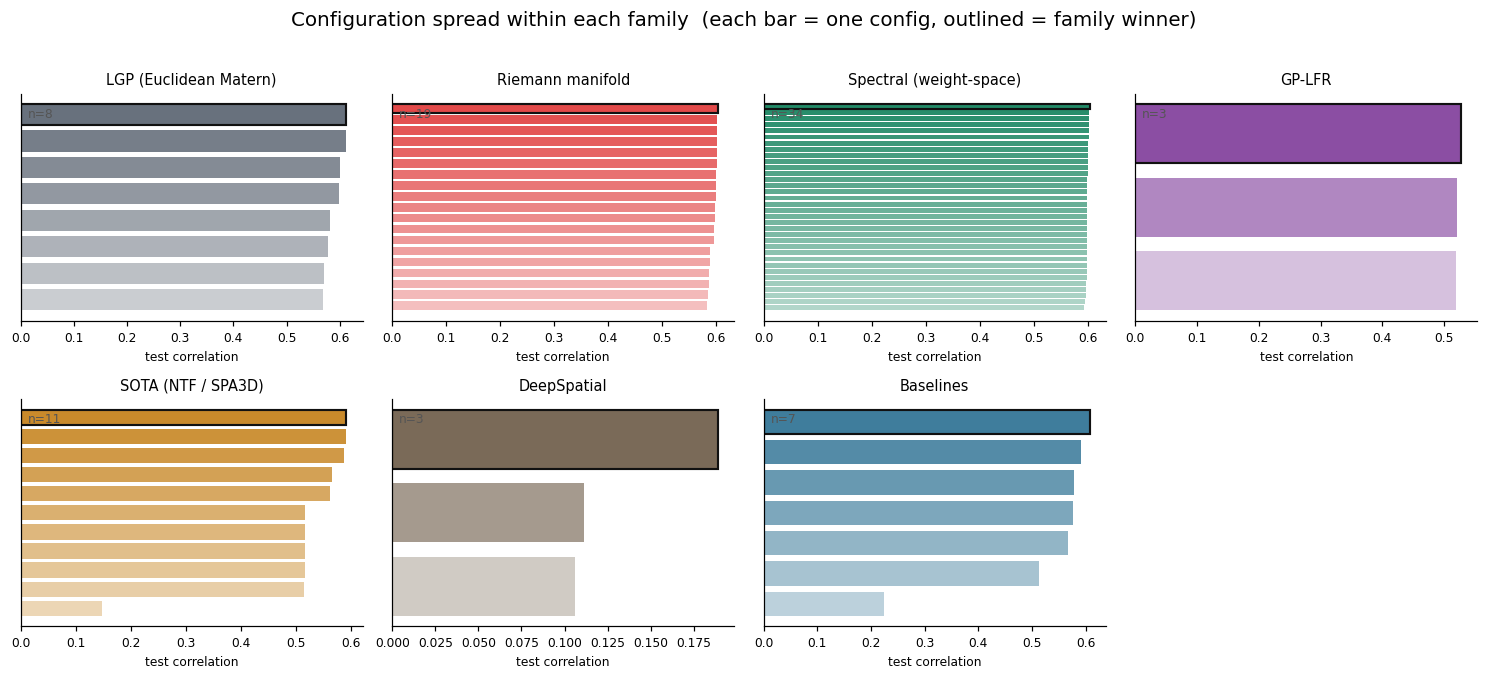

In [10]:
# within-family correlation spread — one small-multiple per family
fams = [f for f in FAMILY_ORDER if f in set(rank.family)]
ncol = 4; nrow = int(np.ceil(len(fams) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 3.0 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, fam in zip(axes, fams):
    g = (rank[rank.family == fam].dropna(subset=["corr"])
             .sort_values("corr").reset_index(drop=True))     # MEAN null has no corr
    col = FAMILY_COLOR[fam]
    y = np.arange(len(g))
    alphas = np.linspace(0.35, 1.0, len(g)) if len(g) > 1 else [1.0]
    for yi, (val, a) in enumerate(zip(g["corr"], alphas)):
        ax.barh(yi, val, color=col, alpha=a, height=0.8)
    ax.barh(len(g) - 1, g["corr"].iloc[-1], color=col, edgecolor=INK, lw=1.4, height=0.8)  # winner
    ax.set_title(FAMILY_LABEL.get(fam, fam).replace("\n", " "), fontsize=9.5)
    ax.set_yticks([]); ax.set_xlabel("test correlation", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.text(0.02, 0.94, f"n={len(g)}", transform=ax.transAxes, fontsize=8,
            va="top", color=INK2)
for ax in axes[len(fams):]:
    ax.axis("off")
fig.suptitle("Configuration spread within each family  (each bar = one config, "
             "outlined = family winner)", fontsize=13, y=1.02)
fig.tight_layout(); plt.show()

### A1c — Headline table: best individual model per *method*

`family` lumps several published methods together (`sota` = NTF **and** SPA3D,
`baseline` = MLP / XGBoost / GCN / …). Here each method gets its own row: we take
the **best configuration of that method by mean test correlation** on the shared
173-lipid × 8-fold panel, so the table reads as *"best LGP vs best manifold vs best
spectral vs GP-LFR vs best NTF vs best SPA3D vs best DeepSpatial vs best MLP …"*.

Because all methods are scored on the same folds, the honest uncertainty is the
**paired** fold-wise difference against the overall winner — the raw `± fold sd`
is mostly *fold difficulty*, which every method shares.

In [11]:
# ---- best individual model per METHOD (finer than the family split) ---------
def method_of(family, model):
    """Split the coarse families into the individual published methods."""
    if family == "sota":
        return "NTF" if "SOTA-NTF" in model else "SPA3D"
    if family == "sota-deepspatial":
        return "DeepSpatial"
    if family == "baseline":
        tok = re.search(r"BASELINES-([A-Z_]+)", model).group(1)
        return {"MLP": "MLP", "MLP_EIGEN": "MLP (eigen-feats)", "GCN_FAISS": "GCN (graph)",
                "XGBOOST": "XGBoost", "LINEAR": "Linear", "MEAN": "Mean (null)",
                # EUCLID's anatomical_interpolation, run unmodified. The four arms
                # (w=0/50 x their leaf atlas / ours) stay separate configurations,
                # so the best-per-method pick below reports the strongest one and
                # A1b still shows the spread across them.
                "EUCLID": "EUCLID (interp.)"}.get(tok, tok)
    return {"lgp": "LGP (Euclidean Matern)", "manifold": "Riemann manifold",
            "spectral": "Spectral (weight-space)", "gplfr": "GP-LFR"}[family]

METHOD_ORDER = ["LGP (Euclidean Matern)", "Riemann manifold", "Spectral (weight-space)",
                "GP-LFR", "NTF", "SPA3D", "DeepSpatial", "EUCLID (interp.)", "MLP",
                "MLP (eigen-feats)", "GCN (graph)", "XGBoost", "Linear", "Mean (null)"]
METHOD_COLOR = {"LGP (Euclidean Matern)": C_E, "Riemann manifold": C_M,
                "Spectral (weight-space)": C_S, "GP-LFR": C_X, "NTF": C_GOLD,
                "SPA3D": C_GOLD, "DeepSpatial": C_TAUPE, "MLP": C_STEEL,
                "MLP (eigen-feats)": C_STEEL, "GCN (graph)": C_STEEL,
                "XGBoost": C_STEEL, "Linear": C_STEEL, "Mean (null)": INK2,
                "EUCLID (interp.)": C_GOLD}

def method_config_label(model):
    """config_summary + the tokens that identify the GP-LFR / DeepSpatial variant."""
    head = [t for t in ("EUCLIDEAN", "RIEMANN", "SPECTRAL", "CROSS", "WITHIN")
            if model.startswith(t)]
    reg = re.search(r"REG\d+", model)
    return " · ".join(head + ([reg.group(0)] if reg else []) + [config_summary(model)])

# per-config aggregate, with a robust median-over-lipids correlation alongside the mean
cfg_m = (per_lipid_model
         .groupby(["family", "model"])
         .agg(corr=("corr_mean", "mean"), corr_med=("corr_mean", "median"),
              r2=("r2_mean", "mean"), rmse=("rmse_mean", "mean"))
         .reset_index())
cfg_m["method"] = [method_of(f, m) for f, m in zip(cfg_m.family, cfg_m.model)]
cfg_m["corr_rank"] = cfg_m["corr"].fillna(-np.inf)      # constant MEAN baseline

# winner per method — same criterion as A1: mean test correlation over the 173 lipids
best_m = (cfg_m.sort_values("corr_rank", ascending=False)
               .drop_duplicates("method", keep="first"))
best_m["n_cfg"] = best_m["method"].map(cfg_m.groupby("method").size())
best_m["ord"] = best_m["method"].map({m: i for i, m in enumerate(METHOD_ORDER)})
best_m = best_m.sort_values("ord").drop(columns="ord").reset_index(drop=True)

# fold-level view: per-fold score = mean over the 173 lipids inside that fold
fold_corr = per_lipid_long.groupby(["model", "fold"])["corr"].mean().unstack()
fold_mse  = per_lipid_long.groupby(["model", "fold"])["mse"].mean().unstack()
ref = best_m.loc[best_m.corr_rank.idxmax(), "model"]      # overall winner = paired reference

rows = []
for _, r in best_m.iterrows():
    d = fold_corr.loc[r.model].values - fold_corr.loc[ref].values     # paired over folds
    rows.append(dict(fold_sd=fold_corr.loc[r.model].std(ddof=1),
                     mse=fold_mse.loc[r.model].mean(),
                     d_corr=d.mean(), d_sd=d.std(ddof=1),
                     d_t=np.nan if np.allclose(d, 0) else d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))))
best_m = pd.concat([best_m, pd.DataFrame(rows)], axis=1)

tbl = pd.DataFrame({
    "method":           best_m.method,
    "corr":             best_m["corr"].round(4),
    "corr (median)":    best_m.corr_med.round(4),
    "± fold sd":        best_m.fold_sd.round(4),
    "R²":               best_m.r2.round(4),
    "RMSE":             best_m.rmse.round(6),
    "MSE ×1e-6":        (best_m.mse * 1e6).round(3),
    "Δ corr vs best":   best_m.d_corr.round(4),
    "± paired sd":      best_m.d_sd.round(4),
    "paired t":         best_m.d_t.round(2),
    "n configs":        best_m.n_cfg,
    "winning config":   best_m.model.map(method_config_label),
}).set_index("method")

display(Markdown(
    f"**Best individual model per method.** Winner of each method by mean test correlation over the "
    f"same {N_LIPIDS} lipids × {N_FOLDS} folds; reference for the paired columns is "
    f"**{method_of(*best_m.loc[best_m.corr_rank.idxmax(), ['family', 'model']])}**. "
    "`± fold sd` is dominated by how hard each CV fold is (it is shared by all methods), so read the "
    "**paired** columns — Δ and its sd are computed fold-by-fold against the winner, "
    "|t| > 2.4 ≈ p < 0.05 (df=7)."))
display(tbl)

**Best individual model per method.** Winner of each method by mean test correlation over the same 173 lipids × 8 folds; reference for the paired columns is **LGP (Euclidean Matern)**. `± fold sd` is dominated by how hard each CV fold is (it is shared by all methods), so read the **paired** columns — Δ and its sd are computed fold-by-fold against the winner, |t| > 2.4 ≈ p < 0.05 (df=7).

,corr,corr (median),± fold sd,R²,RMSE,MSE ×1e-6,Δ corr vs best,± paired sd,paired t,n configs,winning config
method,,,,,,,,,,,
LGP (Euclidean Matern),0.6127,0.6136,0.0319,0.3753,0.000598,2.155,0.0000,0.0000,NaN,8,learnind · ard10 · MEAN · data
Riemann manifold,0.6046,0.6063,0.0329,0.3646,0.000603,2.197,-0.0081,0.0063,-3.60,19,K100 · faiss_atlas_weighted · randomwalk · learndiff1.0 · blend0.8...
Spectral (weight-space),0.6033,0.6049,0.0297,0.3615,0.000605,2.213,-0.0094,0.0054,-4.90,34,SPECTRAL · K300 · faiss_cluster_weighted · randomwalk · reference ...
GP-LFR,0.5275,0.5356,0.0290,0.2800,0.000640,2.380,-0.0852,0.0070,-34.28,3,EUCLIDEAN · d8
NTF,0.5164,0.5125,0.0276,0.1818,0.000684,2.782,-0.0962,0.0056,-48.66,5,TV05 · RES128 · NTF
SPA3D,0.5918,0.5957,0.0267,0.3506,0.000609,2.210,-0.0209,0.0068,-8.65,6,ZW05 · NONE · SPA3D
DeepSpatial,0.1891,0.1875,0.1043,-15.3364,0.000916,3.651,-0.4236,0.1235,-9.70,3,WITHIN · REG03 · WITHIN
MLP,0.6073,0.6089,0.0288,0.3705,0.000602,2.194,-0.0053,0.0039,-3.85,1,MLP
MLP (eigen-feats),0.5786,0.5700,0.0671,0.2974,0.000633,2.443,-0.0341,0.0374,-2.57,3,prune0.9710 · rootdissolve · dn3 · MLP · MLP_EIGEN · NM300


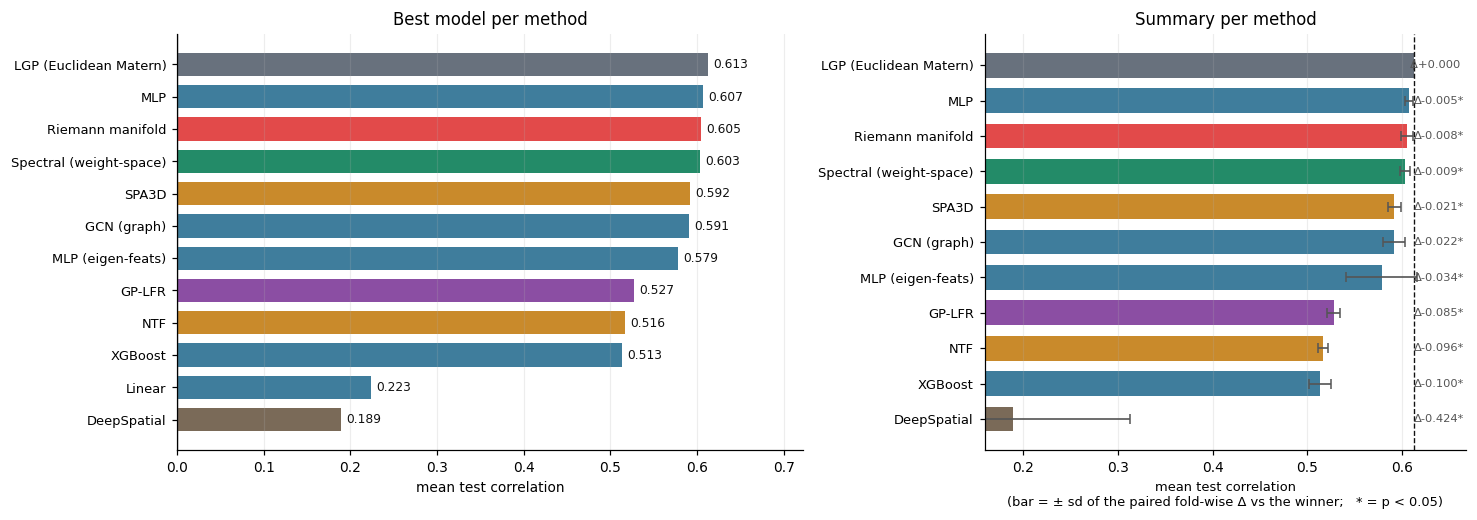

In [12]:
# ---- ranked view of the same table ------------------------------------------
r = best_m.dropna(subset=["corr"]).sort_values("corr").reset_index(drop=True)   # drop MEAN null
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8),
                         gridspec_kw=dict(width_ratios=[1.3, 1]))

ax = axes[0]
y = np.arange(len(r))
ax.barh(y, r["corr"], color=[METHOD_COLOR[m] for m in r.method], height=0.72)
ax.set_yticks(y); ax.set_yticklabels(r.method, fontsize=8.5)
ax.axvline(0, color=INK2, lw=0.9)
ax.set_xlim(0, r["corr"].max() * 1.18)
ax.set_xlabel("mean test correlation"); ax.set_title("Best model per method")
for yi, v in zip(y, r["corr"]):
    ax.text(v + 0.006, yi, f"{v:.3f}", va="center", ha="left", fontsize=8, color=INK)
ax.grid(axis="y", visible=False)

# right panel: the close field, with the paired-vs-winner error bars.
# ALWAYS_SHOW keeps a published method in the panel even when it falls far below
# the cutoff -- DeepSpatial scores 0.19, so the threshold alone would drop it.
CONTENDER_MIN = 0.45
ALWAYS_SHOW = {"DeepSpatial"}
ax = axes[1]
z = r[(r["corr"] > CONTENDER_MIN) | (r.method.isin(ALWAYS_SHOW))].reset_index(drop=True)
y = np.arange(len(z))
ax.barh(y, z["corr"], xerr=z.d_sd, color=[METHOD_COLOR[m] for m in z.method],
        height=0.7, error_kw=dict(ecolor=INK2, lw=1.1, capsize=3))
ax.set_yticks(y); ax.set_yticklabels(z.method, fontsize=8.5)
ax.set_xlim(z["corr"].min() - 0.03, z["corr"].max() + 0.055)
ax.axvline(z["corr"].max(), color=INK, lw=0.9, ls="--")
# the suptitle used to carry the significance legend, so it moves into the label
ax.set_xlabel("mean test correlation\n"
              "(bar = ± sd of the paired fold-wise Δ vs the winner;   * = p < 0.05)",
              fontsize=8.5)
ax.set_title("Summary per method")
for yi, (d, t) in enumerate(zip(z.d_corr, z.d_t)):
    ax.annotate(f"Δ{d:+.3f}" + ("*" if abs(t) > 2.365 else " "), xy=(0.995, yi),
                xycoords=("axes fraction", "data"), ha="right", va="center",
                fontsize=7.5, color=INK2)
ax.grid(axis="y", visible=False)

fig.tight_layout(); plt.show()

## A2 — Correlation and MSE across the best configs, per method (fold error bars)

For each family's winning config we compute a **per-fold** score by averaging over
the 173 lipids within each fold, then plot the **mean ± std across the 8 folds**.
Correlation leads; MSE = mean(RMSE²) is shown beside it as the error-scale view.

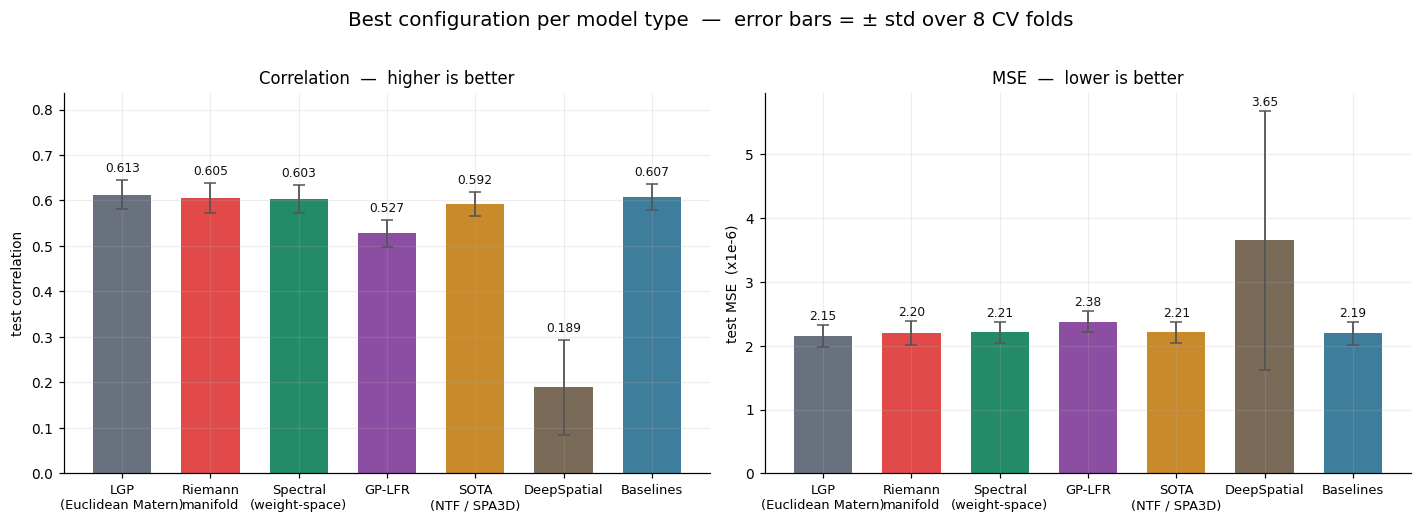

In [ ]:
def fold_scores(model, metric):
    """Per-fold value = mean over lipids within the fold. Returns array of folds."""
    d = per_lipid_long[per_lipid_long.model == model]
    return d.groupby("fold")[metric].mean().values

# Split by METHOD, not family: "Baselines" was one bar hiding six unrelated models
# (and now EUCLID too), which made the tallest baseline invisible and the bar itself
# meaningless. best_m (A1c) already holds the winning config per method.

# Hidden from THIS FIGURE ONLY -- these methods stay in the data, in A1/A1b/A1c and
# in every other section; this just trims the bar chart. Comment a line out to show
# one again, or add "Riemann manifold" here if you want the manifold hidden too
# (it has its own head-to-head in A3 and ablation in A4).
A2_HIDE = {
    "MLP (eigen-feats)",
    "GCN (graph)",
    "Mean (null)",
}

rows = []
for _, r in best_m.iterrows():
    if r.method in A2_HIDE:
        continue
    mse  = fold_scores(r.model, "mse")
    corr = fold_scores(r.model, "corr")
    if len(corr) == 0:
        continue
    rows.append(dict(method=r.method,
                     mse_mean=np.nanmean(mse),   mse_std=np.nanstd(mse, ddof=1),
                     corr_mean=np.nanmean(corr), corr_std=np.nanstd(corr, ddof=1),
                     n_folds=len(corr)))
bar = pd.DataFrame(rows)
bar["ord"] = bar["method"].map({m: i for i, m in enumerate(METHOD_ORDER)})
bar = bar.sort_values("ord").drop(columns="ord").reset_index(drop=True)
bar["color"] = bar["method"].map(METHOD_COLOR).fillna(C_STEEL)
# the constant Mean baseline has undefined correlation; keep the MSE bar, drop the corr one
bar["corr_plot"] = bar["corr_mean"].fillna(0.0)

x = np.arange(len(bar))
fig, axes = plt.subplots(1, 2, figsize=(max(9, 1.05 * len(bar) + 3), 5.0))

# --- correlation (higher is better) - the headline metric ---
ax = axes[0]
ax.bar(x, bar.corr_plot, yerr=bar.corr_std.fillna(0), color=bar.color,
       width=0.7, capsize=3, error_kw=dict(ecolor=INK2, lw=1.1))
ax.set_xticks(x); ax.set_xticklabels(bar.method, fontsize=8, rotation=32, ha="right")
ax.set_ylabel("test correlation"); ax.set_title("Correlation")
ax.set_ylim(0, min(1.0, np.nanmax(bar.corr_plot + bar.corr_std.fillna(0)) + 0.12))
for xi, v, s, raw in zip(x, bar.corr_plot, bar.corr_std.fillna(0), bar.corr_mean):
    ax.text(xi, v + s + 0.012, "n/a" if pd.isna(raw) else f"{raw:.3f}",
            ha="center", va="bottom", fontsize=7.5, color=INK)

# --- MSE (lower is better): scale to 1e-6 for readability ---
sc = 1e6
ax = axes[1]
ax.bar(x, bar.mse_mean * sc, yerr=bar.mse_std * sc, color=bar.color,
       width=0.7, capsize=3, error_kw=dict(ecolor=INK2, lw=1.1))
ax.set_xticks(x); ax.set_xticklabels(bar.method, fontsize=8, rotation=32, ha="right")
ax.set_ylabel("test MSE  (x1e-6)"); ax.set_title("MSE")
for xi, v, s in zip(x, bar.mse_mean * sc, bar.mse_std * sc):
    ax.text(xi, v + s + 0.01 * bar.mse_mean.max() * sc, f"{v:.2f}",
            ha="center", va="bottom", fontsize=7.5, color=INK)

fig.suptitle("Best configuration per METHOD  -  error bars = +/- std over 8 CV folds"
             + (f"   (hidden: {', '.join(sorted(A2_HIDE))})" if A2_HIDE else ""),
             fontsize=12, y=1.03)
fig.tight_layout(); plt.show()

print(bar[["method", "corr_mean", "corr_std", "mse_mean", "n_folds"]]
      .round({"corr_mean": 4, "corr_std": 4}).to_string(index=False))


## A3 — Head-to-head: best Riemann manifold vs best LGP Euclidean

We pit the winning **manifold** config against the winning **LGP** (Euclidean
Matérn) config, lipid-by-lipid, on the shared 173 lipids. Δ = manifold − LGP on
**correlation**; the manifold *wins* a lipid when its correlation is higher (the R²
verdict is printed alongside).

In [14]:
man_model = best.loc[best.family == "manifold", "model"].iloc[0]
lgp_model = best.loc[best.family == "lgp",      "model"].iloc[0]
print("manifold :", man_model)
print("lgp      :", lgp_model)

def per_lipid_vals(model):
    d = per_lipid_model[per_lipid_model.model == model]
    return d.set_index("lipid")[["corr_mean", "r2_mean"]]

m = per_lipid_vals(man_model); l = per_lipid_vals(lgp_model)
h2h = m.join(l, lsuffix="_man", rsuffix="_lgp").dropna()
h2h["d_corr"] = h2h.corr_mean_man - h2h.corr_mean_lgp
h2h["d_r2"]   = h2h.r2_mean_man   - h2h.r2_mean_lgp
h2h["man_wins_corr"] = h2h.d_corr > 0
h2h["man_wins_r2"]   = h2h.d_r2   > 0

n = len(h2h)
print(f"\nlipids compared : {n}")
print(f"manifold wins corr : {h2h.man_wins_corr.sum():3d} / {n}  ({h2h.man_wins_corr.mean()*100:.1f}%)")
print(f"manifold wins R2   : {h2h.man_wins_r2.sum():3d} / {n}  ({h2h.man_wins_r2.mean()*100:.1f}%)")
print(f"mean d_corr = {h2h.d_corr.mean():+.4f}   median = {h2h.d_corr.median():+.4f}")
print(f"mean d_R2   = {h2h.d_r2.mean():+.4f}   median = {h2h.d_r2.median():+.4f}")

manifold : MANIFOLD-RSAMPLE-5-4-K100-reference-5-data-2000-1000-faiss_atlas_weighted-50-15-randomwalk-2-1.0-0.01-0.1-learndiff1.0-blend0.810
lgp      : LGPALL-MEAN-5-data-2000-1000-learnind-ard10

lipids compared : 173
manifold wins corr :   0 / 173  (0.0%)
manifold wins R2   :   0 / 173  (0.0%)
mean d_corr = -0.0081   median = -0.0076
mean d_R2   = -0.0107   median = -0.0101


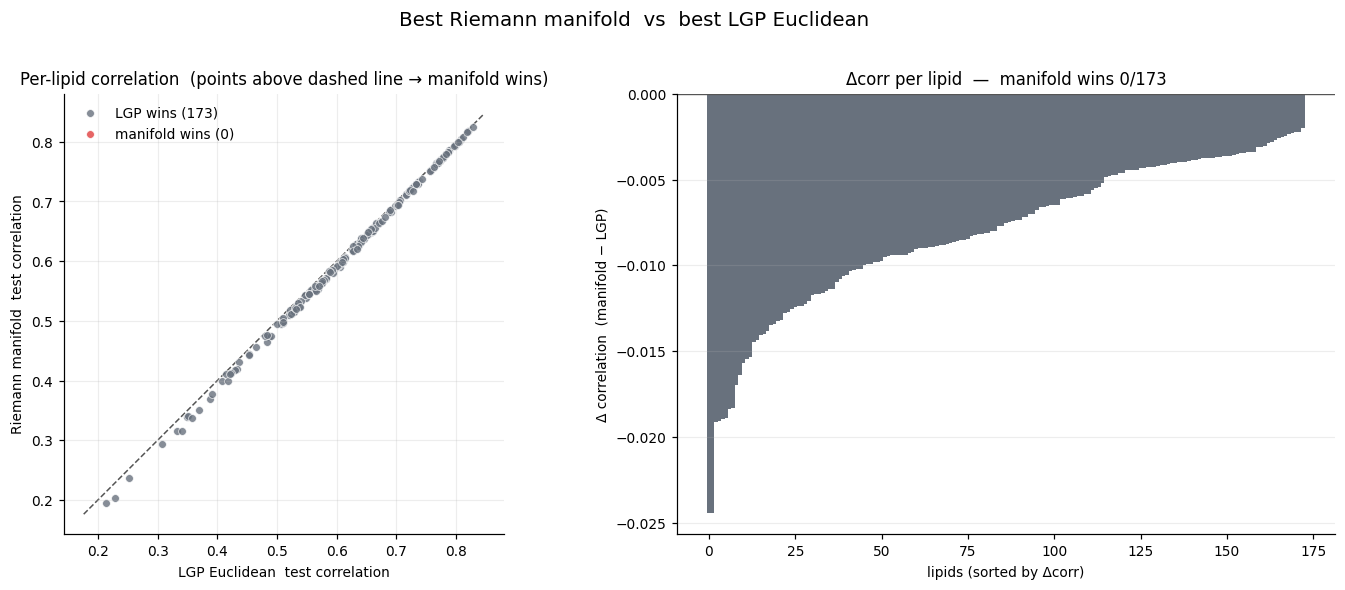

In [15]:
# scatter (identity line) + Delta-correlation distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

ax = axes[0]
win = h2h.man_wins_corr
lo = min(h2h.corr_mean_man.min(), h2h.corr_mean_lgp.min())
hi = max(h2h.corr_mean_man.max(), h2h.corr_mean_lgp.max())
pad = 0.03 * (hi - lo)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=INK2, lw=1, ls="--", zorder=1)
ax.scatter(h2h.corr_mean_lgp[~win], h2h.corr_mean_man[~win], s=26, color=DIVER[1],
           alpha=0.8, edgecolor=SURFACE, lw=0.5, label=f"LGP wins ({(~win).sum()})")
ax.scatter(h2h.corr_mean_lgp[win],  h2h.corr_mean_man[win],  s=26, color=DIVER[0],
           alpha=0.85, edgecolor=SURFACE, lw=0.5, label=f"manifold wins ({win.sum()})")
ax.set_xlabel("LGP Euclidean  test correlation"); ax.set_ylabel("Riemann manifold  test correlation")
ax.set_title("Per-lipid correlation  (points above dashed line → manifold wins)")
ax.set_aspect("equal"); ax.legend(frameon=False, fontsize=9, loc="upper left")

ax = axes[1]
d = h2h.d_corr.sort_values().values
cols = np.where(d > 0, DIVER[0], DIVER[1])
ax.bar(np.arange(len(d)), d, color=cols, width=1.0)
ax.axhline(0, color=INK2, lw=0.9)
ax.set_xlabel("lipids (sorted by Δcorr)"); ax.set_ylabel("Δ correlation  (manifold − LGP)")
ax.set_title(f"Δcorr per lipid  —  manifold wins {win.sum()}/{n}")
ax.grid(axis="x", visible=False)

fig.suptitle("Best Riemann manifold  vs  best LGP Euclidean", fontsize=13, y=1.02)
fig.tight_layout(); plt.show()

In [16]:
# ---- lipids where the manifold wins (ranked by correlation gain) ----------
winners = (h2h[h2h.man_wins_corr]
           .sort_values("d_corr", ascending=False)
           [["corr_mean_man", "corr_mean_lgp", "d_corr", "d_r2"]]
           .rename(columns={"corr_mean_man": "corr_manifold", "corr_mean_lgp": "corr_lgp"}))
print(f"{len(winners)} lipids where the Riemann manifold beats LGP (by correlation):\n")
winners.round(4)

0 lipids where the Riemann manifold beats LGP (by correlation):



,corr_manifold,corr_lgp,d_corr,d_r2
lipid,,,,


## A4 — Manifold ablation: what do modes, pruning & the atlas actually buy?

The 19 manifold runs form a near-factorial grid over

| factor | levels |
|---|---|
| `modes` — Laplacian eigenmodes K | 100 / 300 / 1300 |
| `prune` — edge-prune quantile | 0.90 / 0.95 / 0.97 |
| `annot` — atlas annotation level | none / `level_5` |
| `prodard` — product-ARD scale | none / 2.5 |
| `cleanup` — `rootdissolve` + `dn3` denoise | on / off (confounded, see below) |

so every factor can be isolated by comparing runs that differ **only** in it
(matched pairs), which cancels the fold and lipid variance that swamps the raw
per-config numbers. All deltas below are on **test correlation**.

In [17]:
# ---- decode every manifold run name into its hyperparameters ----------------
# run tag layout (local_run/run_manifold.sh):
#   MANIFOLD-<sampling>-<latent>-<stride>-K<num_modes>-<template>-<threshold>
#   -<inducing_source>-<n_inducing>-<batch>-<knn_method>-<inflation>-<knn_k>
#   -<lap_norm>-<nu>-<bump_scale>-<bump_decay>-<graph_bw>  [+ suffix flags]
def parse_manifold(name):
    return dict(
        modes   = int(re.search(r"K(\d+)", name).group(1)),
        inducing= int(re.search(r"-data-(\d+)-", name).group(1)),
        graph   = ("atlas-weighted" if "faiss_atlas_weighted" in name else
                   "cluster-weighted" if "faiss_cluster_weighted" in name else "plain faiss"),
        annot   = "level_5" if "level_5annot" in name else "—",
        cleanup = "rootdissolve+dn3" if "rootdissolve" in name else "—",
        prune   = (re.search(r"prune(0\.97|0\.95|0\.9)", name).group(1) if "prune" in name else "—"),
        prodard = "2.5" if "prodard" in name else "—",
    )

FACTORS = ["modes", "inducing", "graph", "annot", "cleanup", "prune", "prodard"]

man_cfg = cfg[cfg.family == "manifold"].copy().reset_index(drop=True)
man_cfg = pd.concat([man_cfg, pd.DataFrame([parse_manifold(m) for m in man_cfg.model])], axis=1)
man_cfg = man_cfg.sort_values("corr", ascending=False).reset_index(drop=True)

# per-fold and per-lipid correlation matrices for the manifold runs (drive the deltas)
man_long   = per_lipid_long[per_lipid_long.family == "manifold"]
CORR_FOLD  = man_long.groupby(["model", "fold"])["corr"].mean().unstack()    # model × 8 folds
CORR_LIPID = man_long.groupby(["model", "lipid"])["corr"].mean().unstack()   # model × 173 lipids

grid = man_cfg[FACTORS + ["corr", "r2", "rmse"]].copy()
grid["± fold sd"] = [CORR_FOLD.loc[m].std(ddof=1) for m in man_cfg.model]
grid["Δ vs best"] = grid["corr"] - grid["corr"].max()
grid.index = ["★ best"] + [f"#{i}" for i in range(2, len(grid) + 1)]
display(Markdown(f"**The full manifold grid** — {len(grid)} configurations, "
                 f"corr {grid['corr'].min():.4f} → {grid['corr'].max():.4f} "
                 f"(total spread {grid['corr'].max() - grid['corr'].min():.4f})."))
display(grid.round({"corr": 4, "r2": 4, "rmse": 6, "± fold sd": 4, "Δ vs best": 4}))

**The full manifold grid** — 19 configurations, corr 0.5838 → 0.6046 (total spread 0.0208).

,modes,inducing,graph,annot,cleanup,prune,prodard,corr,r2,rmse,± fold sd,Δ vs best
★ best,100,2000,atlas-weighted,—,—,—,—,0.6046,0.3646,0.000603,0.0329,0.0000
#2,100,1000,atlas-weighted,—,rootdissolve+dn3,0.97,—,0.6037,0.3639,0.000604,0.0326,-0.0010
#3,100,1000,atlas-weighted,—,rootdissolve+dn3,0.95,—,0.6035,0.3639,0.000603,0.0315,-0.0011
#4,100,1000,atlas-weighted,—,rootdissolve+dn3,0.9,—,0.6026,0.3632,0.000604,0.0323,-0.0020
#5,100,1000,atlas-weighted,level_5,rootdissolve+dn3,0.95,—,0.6025,0.3629,0.000604,0.0312,-0.0021
#6,100,1000,atlas-weighted,level_5,rootdissolve+dn3,0.97,—,0.6020,0.3628,0.000604,0.0348,-0.0026
#7,300,1000,atlas-weighted,—,rootdissolve+dn3,0.95,—,0.6009,0.3606,0.000605,0.0314,-0.0037
#8,100,1000,atlas-weighted,level_5,rootdissolve+dn3,0.9,—,0.6007,0.3589,0.000606,0.0372,-0.0039
#9,300,1000,atlas-weighted,level_5,rootdissolve+dn3,0.9,—,0.6003,0.3581,0.000606,0.0325,-0.0044
#10,300,1000,atlas-weighted,—,rootdissolve+dn3,0.9,—,0.5988,0.3558,0.000607,0.0326,-0.0058


In [18]:
# ---- matched-pair marginal effect of each hyperparameter --------------------
# For a contrast A vs B we only use pairs of runs that are identical in *every*
# other factor, so the delta is a clean one-factor-at-a-time ablation.
def matched_pairs(factor, level_to, level_from):
    other = [c for c in FACTORS if c != factor]
    A = man_cfg[man_cfg[factor].astype(str) == str(level_to)]
    B = man_cfg[man_cfg[factor].astype(str) == str(level_from)]
    pairs = []
    for _, ra in A.iterrows():
        hit = B[(B[other].astype(str) == ra[other].astype(str)).all(axis=1)]
        pairs += [(ra.model, mb) for mb in hit.model]
    return pairs

def contrast(factor, level_to, level_from, label=None):
    pairs = matched_pairs(factor, level_to, level_from)
    if not pairs:
        return None
    d_fold  = np.mean([CORR_FOLD.loc[a].values  - CORR_FOLD.loc[b].values  for a, b in pairs], axis=0)
    d_lipid = np.mean([CORR_LIPID.loc[a].values - CORR_LIPID.loc[b].values for a, b in pairs], axis=0)
    return dict(factor=factor, change=label or f"{level_from} → {level_to}",
                n_pairs=len(pairs), d_corr=d_fold.mean(), fold_sd=d_fold.std(ddof=1),
                t=d_fold.mean() / (d_fold.std(ddof=1) / np.sqrt(len(d_fold))),
                lipids_improved=(d_lipid > 0).mean())

CONTRASTS = [
    ("modes",   300, 100,  "100 → 300 modes"),
    ("modes",  1300, 300,  "300 → 1300 modes"),
    ("modes",  1300, 100,  "100 → 1300 modes"),
    ("prune",  "0.95", "0.9",  "prune 0.90 → 0.95"),
    ("prune",  "0.97", "0.9",  "prune 0.90 → 0.97"),
    ("prune",  "0.97", "0.95", "prune 0.95 → 0.97"),
    ("annot",  "level_5", "—", "add atlas annot (level_5)"),
    ("prodard", "2.5", "—",    "add product-ARD 2.5"),
]
marg = pd.DataFrame([c for c in (contrast(*c) for c in CONTRASTS) if c])
# significant if the paired fold t-test fires, or if the sign is consistent over lipids
sig = (marg.t.abs() > 2.365) | (marg.lipids_improved < 0.05) | (marg.lipids_improved > 0.95)
marg["verdict"] = np.where(~sig, "flat (within noise)",
                           np.where(marg.d_corr > 0, "helps", "hurts"))
display(Markdown("**Matched-pair ablation** — each row averages the Δcorrelation over every pair of "
                 "runs that differ *only* in that factor. `fold sd` is the spread of the delta over "
                 "the 8 CV folds; `t` is the paired t-statistic over folds (|t| > 2.4 ≈ p < 0.05, "
                 "df=7); `lipids improved` is the fraction of the 173 lipids that got better."))
display(marg.rename(columns={"d_corr": "Δ corr", "fold_sd": "fold sd",
                             "lipids_improved": "lipids improved"})
            .set_index(["factor", "change"])
            .round({"Δ corr": 4, "fold sd": 4, "t": 2, "lipids improved": 3}))

# the one comparison that is NOT matched: graph cleanup is confounded with M
raw   = man_cfg[man_cfg.cleanup == "—"].iloc[0]
clean = man_cfg[(man_cfg.modes == raw.modes) & (man_cfg.cleanup != "—") &
                (man_cfg.annot == "—")].sort_values("corr", ascending=False).iloc[0]
d = CORR_FOLD.loc[raw.model].values - CORR_FOLD.loc[clean.model].values
print(f"\nUnmatched (confounded) comparison — graph cleanup + inducing points, both at K={raw.modes}:")
print(f"  no cleanup, M={raw.inducing:<5d} inducing : corr = {raw['corr']:.4f}")
print(f"  rootdissolve+dn3+prune{clean.prune}, M={clean.inducing} : corr = {clean['corr']:.4f}")
print(f"  Δ = {d.mean():+.4f} ± {d.std(ddof=1):.4f} (fold sd)  →  the two knobs move together here,"
      f"\n  so this row cannot separate 'cleanup hurts' from 'M=2000 helps'. The kernel is rank"
      f"\n  {raw.modes}, so extra inducing points beyond {raw.modes} add no capacity — which argues"
      "\n  the difference is the graph cleanup, but it is not a controlled test.")

**Matched-pair ablation** — each row averages the Δcorrelation over every pair of runs that differ *only* in that factor. `fold sd` is the spread of the delta over the 8 CV folds; `t` is the paired t-statistic over folds (|t| > 2.4 ≈ p < 0.05, df=7); `lipids improved` is the fraction of the 173 lipids that got better.

n_pairs  Δ corr  fold sd     t  \
factor  change                                                      
modes   100 → 300 modes                  6 -0.0036   0.0055 -1.85   
        300 → 1300 modes                 3 -0.0115   0.0091 -3.59   
        100 → 1300 modes                 3 -0.0157   0.0089 -5.01   
prune   prune 0.90 → 0.95                6 -0.0007   0.0032 -0.66   
        prune 0.90 → 0.97                6 -0.0008   0.0031 -0.69   
        prune 0.95 → 0.97                6 -0.0000   0.0013 -0.01   
annot   add atlas annot (level_5)        6 -0.0008   0.0025 -0.93   
prodard add product-ARD 2.5              3 -0.0002   0.0037 -0.13   

                                   lipids improved              verdict  
factor  change                                                           
modes   100 → 300 modes                      0.017                hurts  
        300 → 1300 modes                     0.006                hurts  
        100 → 1300 modes                     0.000                hurts  
prune   prune 0.90 → 0.95                    0.237  flat (within noise)  
        prune 0.90 → 0.97                    0.295  flat (within noise)  
        prune 0.95 → 0.97                    0.462  flat (within noise)  
annot   add atlas annot (level_5)            0.387  flat (within noise)  
prodard add product-ARD 2.5                  0.503  flat (within noise)


Unmatched (confounded) comparison — graph cleanup + inducing points, both at K=100:
  no cleanup, M=2000  inducing : corr = 0.6046
  rootdissolve+dn3+prune0.97, M=1000 : corr = 0.6037
  Δ = +0.0010 ± 0.0054 (fold sd)  →  the two knobs move together here,
  so this row cannot separate 'cleanup hurts' from 'M=2000 helps'. The kernel is rank
  100, so extra inducing points beyond 100 add no capacity — which argues
  the difference is the graph cleanup, but it is not a controlled test.


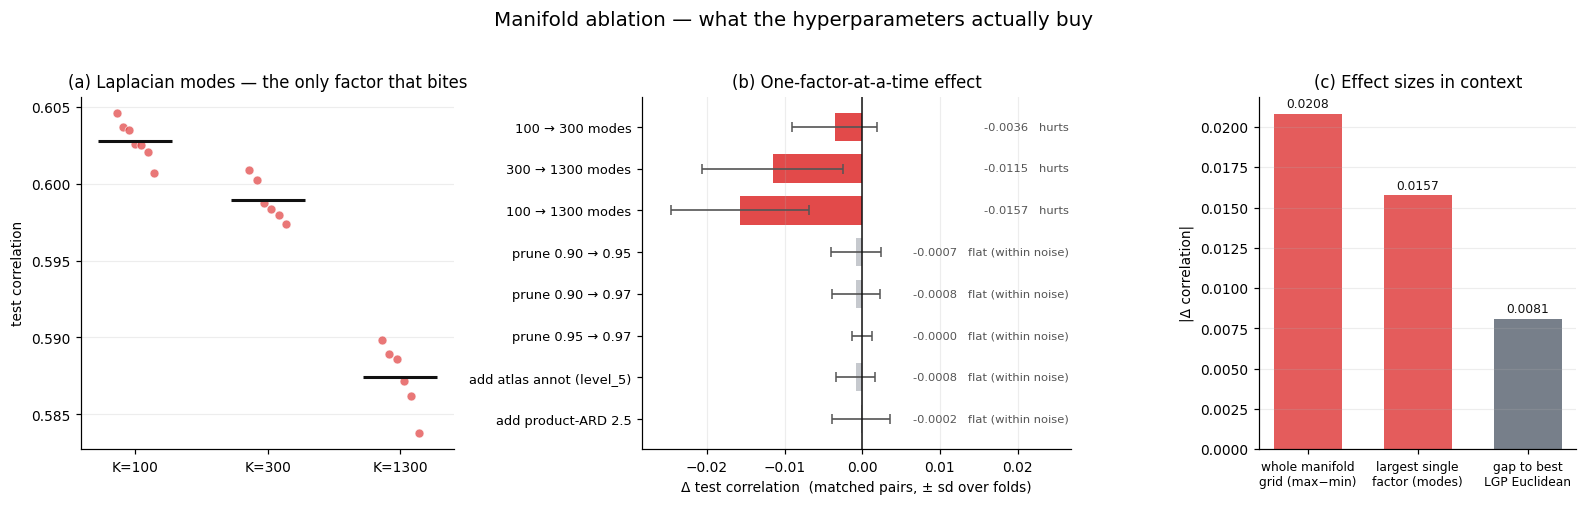

In [19]:
# ---- ablation figure: mode sweep, factor tornado, effect vs family gap ------
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4),
                         gridspec_kw=dict(width_ratios=[1, 1.15, 0.85]))

# (a) modes: every config, grouped by K
ax = axes[0]
for i, k in enumerate(sorted(man_cfg.modes.unique())):
    g = man_cfg[man_cfg.modes == k]
    x = np.full(len(g), i) + np.linspace(-0.14, 0.14, len(g))
    ax.scatter(x, g["corr"], s=34, color=C_M, alpha=0.75, edgecolor=SURFACE, lw=0.5, zorder=3)
    ax.hlines(g["corr"].mean(), i - 0.28, i + 0.28, color=INK, lw=2, zorder=4)
ax.set_xticks(range(man_cfg.modes.nunique()))
ax.set_xticklabels([f"K={k}" for k in sorted(man_cfg.modes.unique())])
ax.set_ylabel("test correlation"); ax.set_title("(a) Laplacian modes — the only factor that bites")
ax.grid(axis="x", visible=False)

# (b) tornado of matched-pair effects
ax = axes[1]
t = marg.iloc[::-1].reset_index(drop=True)
y = np.arange(len(t))
cols = [C_M if s else "#c6c9ce" for s in (t.verdict != "flat (within noise)")]
ax.barh(y, t.d_corr, xerr=t.fold_sd, color=cols, height=0.68,
        error_kw=dict(ecolor=INK2, lw=1.1, capsize=3))
ax.axvline(0, color=INK, lw=1)
ax.set_yticks(y); ax.set_yticklabels(t.change, fontsize=8.5)
ax.set_xlabel("Δ test correlation  (matched pairs, ± sd over folds)")
ax.set_title("(b) One-factor-at-a-time effect")
ax.grid(axis="y", visible=False)
lo = min(0, (t.d_corr - t.fold_sd).min()) * 1.15
ax.set_xlim(lo, max((t.d_corr + t.fold_sd).max() * 1.3, -lo * 0.95))
for yi, (v, ver) in enumerate(zip(t.d_corr, t.verdict)):
    ax.annotate(f"{v:+.4f}   {ver}", xy=(0.995, yi), xycoords=("axes fraction", "data"),
                ha="right", va="center", fontsize=7.5, color=INK2)

# (c) how big are these knobs next to the between-method gaps?
ax = axes[2]
span_manifold = man_cfg["corr"].max() - man_cfg["corr"].min()
span_tuning   = marg.d_corr.abs().max()
gap_lgp       = cfg.loc[cfg.family == "lgp", "corr"].max() - man_cfg["corr"].max()
bars  = [span_manifold, span_tuning, abs(gap_lgp)]
names = ["whole manifold\ngrid (max−min)", "largest single\nfactor (modes)", "gap to best\nLGP Euclidean"]
ax.bar(range(3), bars, color=[C_M, C_M, C_E], width=0.62, alpha=0.9)
ax.set_xticks(range(3)); ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("|Δ correlation|"); ax.set_title("(c) Effect sizes in context")
for i, v in enumerate(bars):
    ax.text(i, v + 0.0004, f"{v:.4f}", ha="center", fontsize=8, color=INK)
ax.grid(axis="x", visible=False)

fig.suptitle("Manifold ablation — what the hyperparameters actually buy", fontsize=13, y=1.03)
fig.tight_layout(); plt.show()

**Reading the ablation.**

- **Modes is the only knob that moves the metric**, and it moves it the *wrong*
  way: 100 → 1300 modes costs ≈0.016 correlation, monotonically, and improves
  **0/173** lipids (100 → 300 already costs 0.0036 and improves only 1.7% of lipids).
  This is the mode-resolution ceiling — beyond what the node density supports the
  extra eigenvectors add aliased high-frequency noise, not capacity. Nothing in
  this grid tests K < 100, which is where the remaining headroom would be.
- **Pruning is inert.** 0.90 → 0.95 → 0.97 moves correlation by ≤0.0008 with |t| < 0.7
  — the prune quantile is not the lever it was assumed to be.
- **Atlas annotation and product-ARD are also flat** (−0.0008 and −0.0002, |t| < 1).
- **Context (panel c):** the whole grid spans 0.021 correlation while the gap between
  the best manifold and the best Euclidean LGP is only 0.008 — i.e. *mis-setting the
  mode count costs ~2× the entire manifold-vs-Euclidean difference*.

## Part B — Per-lipid dedicated models  (`report_per_lipid/`)

Here five focus lipids each get their **own** dedicated model, swept over Euclidean
/ manifold / spectral kernels. The `[full]` rows are the whole-brain LGP model's
performance on those same lipids, carried over for comparison.

In [20]:
plm  = pd.read_csv(PL / "per_lipid_model.csv")     # (lipid, model, kernel_family), incl [full]
pll  = pd.read_csv(PL / "per_lipid_long.csv")      # per-fold, dedicated models only
uplift = pd.read_csv(PL / "full_lgp_uplift.csv")
fvp    = pd.read_csv(PL / "full_vs_per_lipid.csv")

FOCUS = sorted(plm["lipid"].unique())
print("focus lipids:", FOCUS)

# tag dedicated (per-lipid) vs full
plm["is_full"] = plm["model"].str.startswith("[full]")
# simple kernel bucket for the dedicated models
def kbucket(kf):
    return {"euclidean": "Euclidean", "manifold": "Manifold",
            "spectral": "Spectral"}.get(kf, kf)
pll["kb"] = pll["kernel_family"].map(kbucket)
KB_COLOR = {"Euclidean": C_E, "Manifold": C_M, "Spectral": C_S, "Full LGP": C_EMP}


focus lipids: ['Hex2Cer 40:1;O2', 'LPC 22:6', 'PA 36:1', 'PC 35:1 PE 38:1', 'PE O-36:0 PE O-38:3']


### B1 — Per-lipid bar plots of the dedicated models

For each focus lipid we take the **best dedicated config within each kernel family**
(by mean test correlation), plot it with **±std across the 8 folds**, and overlay the
whole-brain **Full LGP** model (dashed line) as the reference to beat. The R² version
of the same panel follows underneath.

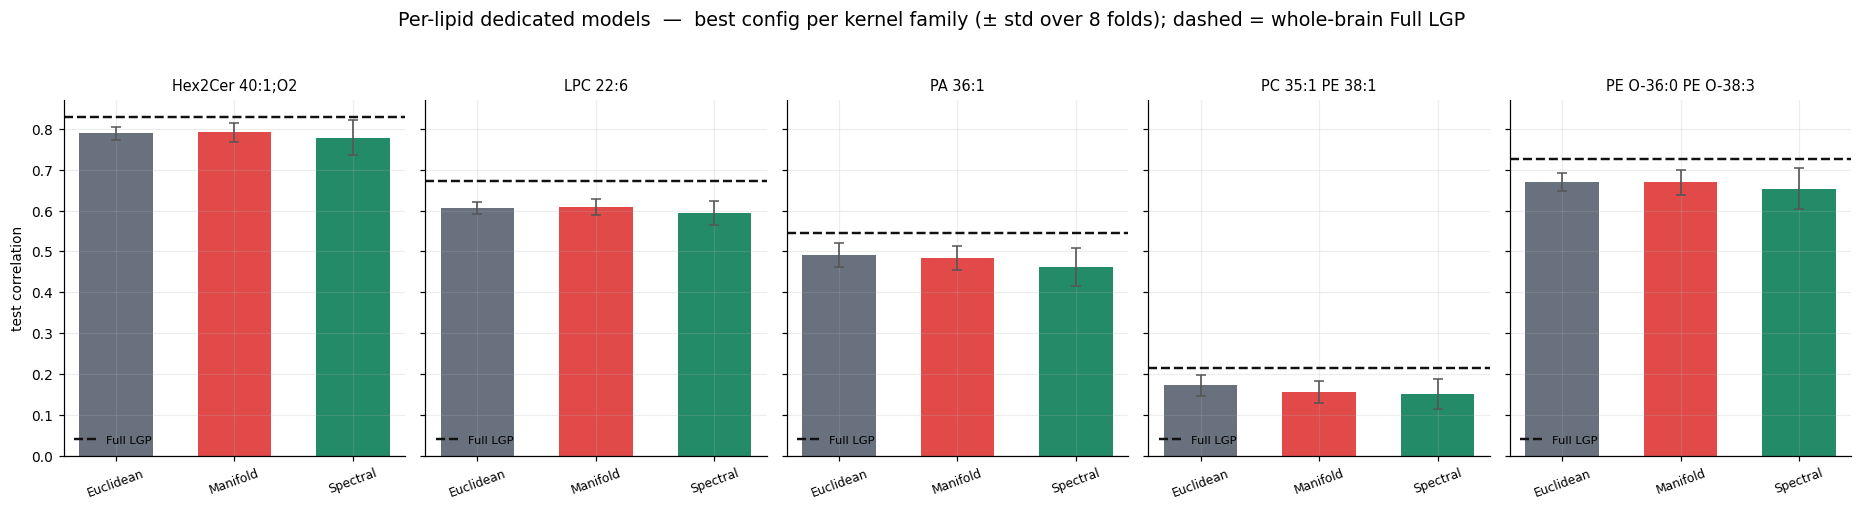

In [21]:
# best dedicated config per (lipid, kernel bucket), with fold error bars from pll
def best_dedicated(lipid):
    d = pll[pll.lipid_name == lipid]
    out = []
    for kb, g in d.groupby("kb"):
        # pick config with best mean test correlation over folds
        by_model = g.groupby("model")["test_corr"].mean()
        bm = by_model.idxmax()
        gg = g[g.model == bm]
        out.append(dict(kb=kb, model=bm,
                        corr=gg["test_corr"].mean(), corr_std=gg["test_corr"].std(ddof=1),
                        r2=gg["test_r2"].mean(), r2_std=gg["test_r2"].std(ddof=1)))
    return pd.DataFrame(out)

# full LGP reference per lipid (best [full] LGPALL config by test_corr_mean)
def full_lgp_ref(lipid):
    d = plm[(plm.lipid == lipid) & (plm.model.str.contains("LGPALL"))]
    if d.empty: return None
    return d.sort_values("test_corr_mean", ascending=False).iloc[0]

fig, axes = plt.subplots(1, len(FOCUS), figsize=(3.4 * len(FOCUS), 4.4), sharey=True)
kb_order = ["Euclidean", "Manifold", "Spectral"]
for ax, lipid in zip(axes, FOCUS):
    bd = best_dedicated(lipid).set_index("kb").reindex(kb_order).dropna(how="all")
    x = np.arange(len(bd))
    ax.bar(x, bd["corr"], yerr=bd["corr_std"], width=0.62, capsize=3,
           color=[KB_COLOR[k] for k in bd.index],
           error_kw=dict(ecolor=INK2, lw=1.1))
    ref = full_lgp_ref(lipid)
    if ref is not None:
        ax.axhline(ref["test_corr_mean"], color=KB_COLOR["Full LGP"], lw=1.6, ls="--",
                   label="Full LGP")
        ax.legend(frameon=False, fontsize=7.5, loc="lower left")
    ax.set_xticks(x); ax.set_xticklabels(bd.index, fontsize=8, rotation=20)
    ax.set_title(lipid, fontsize=9.5)
    ax.axhline(0, color=INK2, lw=0.7)
axes[0].set_ylabel("test correlation")
fig.suptitle("Per-lipid dedicated models  —  best config per kernel family "
             "(± std over 8 folds); dashed = whole-brain Full LGP",
             fontsize=12.5, y=1.04)
fig.tight_layout(); plt.show()

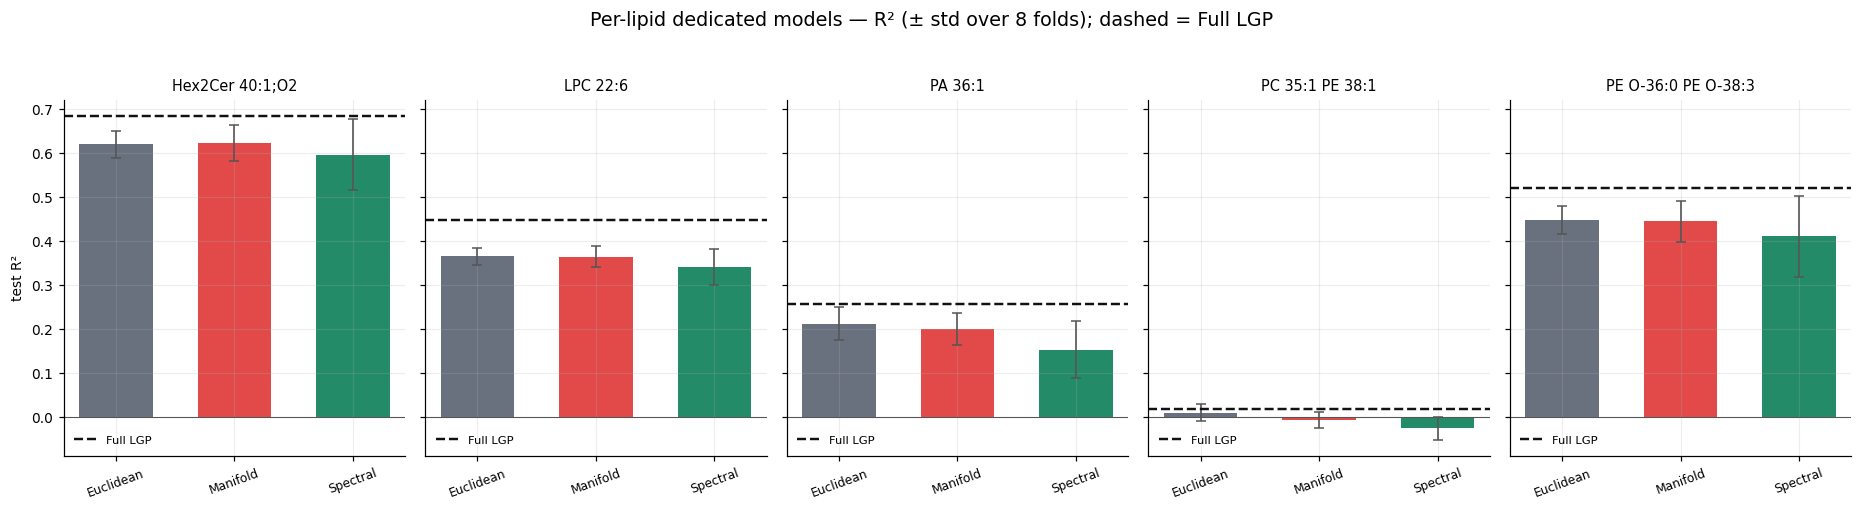

In [22]:
# same, for R² (secondary metric)
fig, axes = plt.subplots(1, len(FOCUS), figsize=(3.4 * len(FOCUS), 4.4), sharey=True)
for ax, lipid in zip(axes, FOCUS):
    bd = best_dedicated(lipid).set_index("kb").reindex(kb_order).dropna(how="all")
    x = np.arange(len(bd))
    ax.bar(x, bd["r2"], yerr=bd["r2_std"], width=0.62, capsize=3,
           color=[KB_COLOR[k] for k in bd.index], error_kw=dict(ecolor=INK2, lw=1.1))
    ref = full_lgp_ref(lipid)
    if ref is not None:
        ax.axhline(ref["test_r2_mean"], color=KB_COLOR["Full LGP"], lw=1.6, ls="--", label="Full LGP")
        ax.legend(frameon=False, fontsize=7.5, loc="lower left")
    ax.set_xticks(x); ax.set_xticklabels(bd.index, fontsize=8, rotation=20)
    ax.set_title(lipid, fontsize=9.5)
    ax.axhline(0, color=INK2, lw=0.7)
axes[0].set_ylabel("test R²")
fig.suptitle("Per-lipid dedicated models — R² (± std over 8 folds); dashed = Full LGP",
             fontsize=12.5, y=1.04)
fig.tight_layout(); plt.show()

### B2 — How much does the full LGP bring on top?

`full_lgp_uplift.csv` compares the whole-brain **Full LGP** model against the
**best single dedicated per-lipid model**, per focus lipid. Positive Δ means the
full multi-lipid model — which borrows strength across all lipids — beats the
bespoke per-lipid fit. Ranked on correlation, with the R² columns alongside.

In [23]:
# headline uplift table (best full LGP config, ranked by its own test correlation)
up = uplift.merge(fvp[["model", "test_corr_mean", "test_r2_mean"]],
                  left_on="full_model", right_on="model", how="left").drop(columns="model")
up = up.sort_values("test_corr_mean", ascending=False).copy()
best_full = up.iloc[0]
print("Best full LGP config:")
print(" ", best_full["full_model"])
print(f"  n_lipids = {int(best_full['n_lipids'])}")
print(f"  corr : full mean = {best_full['test_corr_mean']:.4f}   "
      f"d_corr mean = {best_full['d_corr_mean']:+.4f}   "
      f"win rate = {best_full['corr_win_rate']*100:.0f}%")
print(f"  R2   : full median = {best_full['r2_full_median']:.4f}   "
      f"best-single median = {best_full['r2_best_single_median']:.4f}   "
      f"d_R2 mean = {best_full['d_r2_mean']:+.4f}   "
      f"win rate = {best_full['r2_win_rate']*100:.0f}%")
up[["full_model", "test_corr_mean", "d_corr_mean", "corr_win_rate",
    "r2_full_median", "r2_best_single_median", "d_r2_mean", "r2_win_rate"]].head(8).round(4)

Best full LGP config:
  [full] LGPALL-MEAN-5-reference-2000-1000-learnind-ard10
  n_lipids = 5
  corr : full mean = 0.5979   d_corr mean = +0.0470   win rate = 100%
  R2   : full median = 0.4270   best-single median = 0.3659   d_R2 mean = +0.0456   win rate = 100%


,full_model,test_corr_mean,d_corr_mean,corr_win_rate,r2_full_median,r2_best_single_median,d_r2_mean,r2_win_rate
0,[full] LGPALL-MEAN-5-reference-2000-1000-learnind-ard10,0.5979,0.0470,1.0,0.4270,0.3659,0.0456,1.0
1,[full] LGPALL-MEAN-5-data-2000-1000-learnind-ard10,0.5964,0.0494,1.0,0.4262,0.3659,0.0488,1.0
2,[full] SPECTRAL-5-4-K300-reference-5-1000-faiss_cluster_weighted-5...,0.5891,0.0398,1.0,0.4143,0.3659,0.0350,0.8
32,[full] MANIFOLD-RSAMPLE-5-4-K100-reference-5-data-2000-1000-faiss_...,0.5885,0.0374,1.0,0.4041,0.3659,0.0305,0.8
16,[full] SPECTRAL-5-4-K300-reference-5-1000-faiss_cluster_weighted-5...,0.5884,0.0404,1.0,0.4081,0.3659,0.0347,0.8
22,[full] SPECTRAL-5-4-K300-reference-5-1000-faiss-1-15-randomwalk-2-...,0.5883,0.0404,1.0,0.4065,0.3659,0.0340,0.8
17,[full] SPECTRAL-5-4-K300-reference-5-1000-faiss-1-15-randomwalk-2-...,0.5879,0.0395,1.0,0.4073,0.3659,0.0311,0.8
28,[full] SPECTRAL-5-4-K300-reference-5-1000-faiss_atlas_weighted-50-...,0.5876,0.0358,1.0,0.4046,0.3659,0.0265,0.8


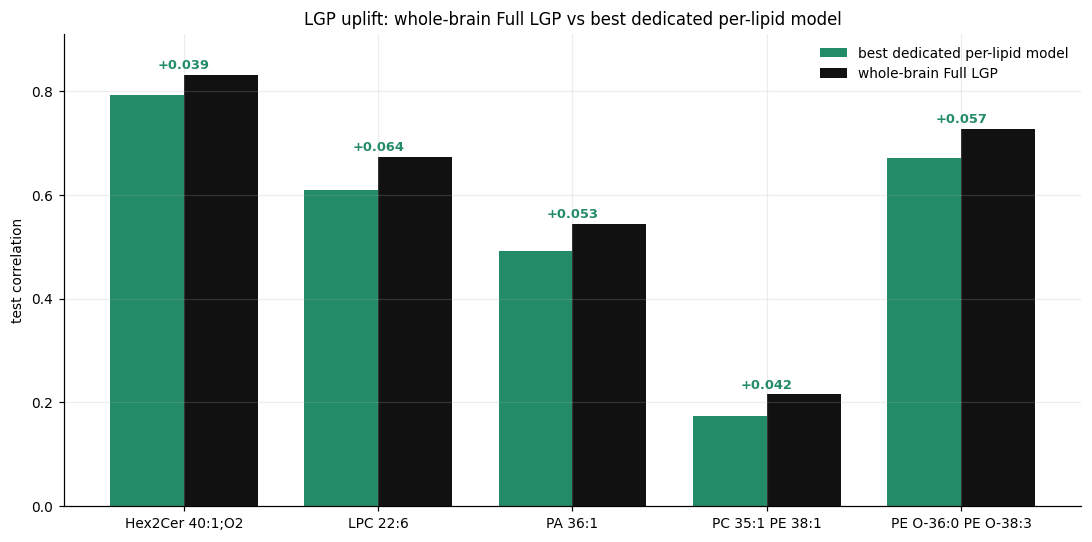

Mean correlation uplift of Full LGP over best per-lipid model: +0.0511 (wins 5/5 lipids)


In [24]:
# per-lipid: Full LGP vs best dedicated model (grouped bars) + uplift arrows
# best full LGP per lipid (by correlation)
full_by_lipid = (plm[plm.model.str.contains("LGPALL")]
                 .sort_values("test_corr_mean", ascending=False)
                 .groupby("lipid").first()["test_corr_mean"])
# best dedicated per lipid (any kernel, by correlation)
ded_by_lipid = (plm[~plm.is_full]
                .sort_values("test_corr_mean", ascending=False)
                .groupby("lipid").first()["test_corr_mean"])

comp = pd.DataFrame({"Full LGP": full_by_lipid, "best per-lipid": ded_by_lipid}).reindex(FOCUS)

x = np.arange(len(comp)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, comp["best per-lipid"], width=w, color=C_S, label="best dedicated per-lipid model")
ax.bar(x + w/2, comp["Full LGP"],       width=w, color=C_EMP, label="whole-brain Full LGP")
for xi, (a, b) in zip(x, comp[["best per-lipid", "Full LGP"]].values):
    d = b - a
    ax.annotate(f"{d:+.3f}", (xi, max(a, b) + 0.012), ha="center", fontsize=8.5,
                color=(C_S if d > 0 else C_M), fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(comp.index, fontsize=9)
ax.set_ylabel("test correlation"); ax.set_ylim(0, comp.values.max() + 0.08)
ax.set_title("LGP uplift: whole-brain Full LGP vs best dedicated per-lipid model")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout(); plt.show()

print("Mean correlation uplift of Full LGP over best per-lipid model: "
      f"{(comp['Full LGP'] - comp['best per-lipid']).mean():+.4f} "
      f"(wins {(comp['Full LGP'] > comp['best per-lipid']).sum()}/{len(comp)} lipids)")

### Takeaways

*(All numbers below are test **correlation**, the headline metric of this notebook.)*

- **A1/A2** rank every configuration within each family and compare the winners on
  correlation and MSE with fold-level error bars — read the *ordering and the
  overlap of the error bars*, not the absolute MSE scale.
- **A1c** is the headline cross-method table: best LGP 0.6127 > MLP 0.6073 > manifold
  0.6046 > spectral 0.6033 > SPA3D 0.5918 > GCN 0.5911 > MLP-eigen 0.5786 > GP-LFR
  0.5275 > NTF 0.5164 > XGBoost 0.5130 > linear 0.2234 > DeepSpatial 0.1171. Read the
  *paired* Δ columns: on correlation the fold-paired error bars are tight enough that
  **every** method separates from the winning LGP, including the plain MLP
  (Δ −0.0053, t = −3.9) — unlike on R², where the MLP gap is not significant.
- **A3** is the core manifold-vs-Euclidean question on the full lipid panel: the
  correlation-best LGP config beats the correlation-best manifold on **all 173
  lipids** (mean Δcorr −0.0081). Note this is stricter than the R²-ranked pairing,
  which left the manifold winning 3–4 lipids — the two metrics pick different LGP
  winners (`-data-` vs `-reference-` inducing points).
- **A4** ablates the manifold grid: the mode count is the only factor with a real
  effect (and fewer modes is better); prune quantile, atlas annotation and
  product-ARD are all inside fold noise.
- **B1/B2** zoom into the five dedicated lipids: within each, the best per-kernel
  dedicated model is compared to the whole-brain Full LGP, quantifying the uplift
  the joint multi-lipid model provides on top of bespoke per-lipid fits.